# **Restaurant Rating Analysis & Prediction Project**

## **Business Case**

- This project helps food delivery platforms and restaurant owners understand what drives higher restaurant ratings.
    
- By analyzing factors like price range, location, votes, and online services, the model can predict restaurant ratings, enabling businesses to:

- Improve customer experience

- Optimize pricing strategies

- Promote high-potential restaurants

- Support data-driven decisions for onboarding, marketing, and visibility

# LEVEL 1 – Exploratory & Analysis

## Import Libraries & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Datasetog.csv")

In [3]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


# Domain Analysis

1. *Restaurant ID* :  
   - datatype : int64  
   - It is a unique identifier for each restaurant in the dataset.  
2. *Restaurant Name* :  
   - datatype : object  
   - It is the name of the restaurant.  
3. *Country Code* :  
   - datatype : int64  
   - It is a numerical code representing the country in which the restaurant is located.  
4. *City* :  
   - datatype : object  
   - It is the name of the city where the restaurant operates.  
5. *Address* :  
   - datatype : object  
   - It is the complete address of the restaurant including street and area details.  
6. *Locality* :  
   *datatype : object  
   - It is the specific area where the restaurant is located.  
7. *Locality Verbose* :  
   - datatype : object  
   - It is the detailed version of locality information.  
8. *Longitude* :  
   - datatype : float64  
   - It is the geographical longitude coordinate of the restaurant's location.  
9. *Latitude* :  
   - datatype : float64  
   - It is the geographical latitude coordinate of the restaurant's location.  
10. *Cuisines* :  
    - datatype : object  
    - It is  types of cuisines served at the restaurant (e.g., “Italian, Chinese, Indian”).  
11. *Average Cost for two* :  
    - datatype : int64  
    - It is the average cost of a meal for two people in the local currency.  
12. *Currency* :  
    - datatype : object  
    - It is the currency in which the restaurant’s prices are listed (e.g., INR, Dollar, Pula).  
13. *Has Table booking* :  
    - datatype : object  
    - It shows whether the restaurant provides an option for table booking ('Yes' or 'No').  
14. *Has Online delivery* :  
    - datatype : object  
    - It shows whether the restaurant offers online delivery services ('Yes' or 'No').  
15. *Is delivering now* :  
    - datatype : object  
    - It shows whether the restaurant is currently accepting online orders ('Yes' or 'No').  
16. *Switch to order menu* :  
    - datatype : object  
    - It shows if users can directly switch to the restaurant’s online order menu (Yes or No).  
17. *Price range* :  
    - datatype : int64  
    - It is a numerical category (usually 1–4) representing the price level of the restaurant, In which higher values indicate  higher cost.  
18. *Aggregate rating* :  
    - datatype : float64  
    - It is the average customer rating of the restaurant,ranging from 0.0 to 5.0.  
19. *Rating color* :  
    - datatype : object  
    - It is the color code corresponding to the rating level.  
20. *Rating text* :  
    - datatype : object  
    - It is the textual representation of the restaurant’s rating.  
21. *Votes* :  
    - datatype : int64  
    - It is the number of customer votes  that contributed to the restaurant’s rating.

## Task 1: Data Exploration & Preprocessing

## Check Rows & Columns

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 9551
Columns: 21


## Check Missing Values

In [5]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

## Convert Data Types

In [6]:
df['Country Code'] = df['Country Code'].astype('category')
df['City'] = df['City'].astype('category')
df['Cuisines'] = df['Cuisines'].astype('category')

* Categorical conversion reduces memory usage

* Improves grouping & aggregation performance

## Analyze Aggregate Rating Distribution

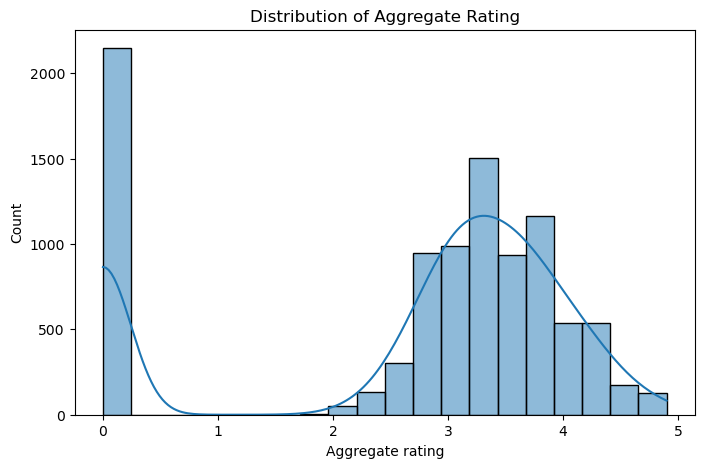

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['Aggregate rating'], bins=20, kde=True)
plt.title("Distribution of Aggregate Rating")
plt.show()

In [8]:
df['Aggregate rating'].value_counts().head()

Aggregate rating
0.0    2148
3.2     522
3.1     519
3.4     498
3.3     483
Name: count, dtype: int64

* Ratings are left-skewed

* Most restaurants lie between 3.0 – 4.5

* Very few restaurants have ratings below 2

## Task 2: Descriptive Analysis

### Mean, Median, Standard Deviation

In [9]:
df.describe()

,Restaurant ID,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


* Average rating ≈ 3.2 – 3.5

* Cost for two shows high variance, indicating price diversity

* Latitude & longitude are well distributed geographically

## Categorical Column Analysis

City Distribution

In [10]:
df['City'].value_counts().head(10)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Amritsar          21
Ahmedabad         21
Guwahati          21
Name: count, dtype: int64

* New Delhi, Gurgaon, Noida dominate restaurant counts

## Country Code Distribution

In [11]:
df['Country Code'].value_counts()

Country Code
1      8652
216     434
215      80
30       60
189      60
214      60
148      40
208      34
14       24
162      22
94       21
166      20
184      20
191      20
37        4
Name: count, dtype: int64

* Majority of restaurants are from India

* Minor presence from other countries

## Cuisines Distribution

In [12]:
df['Cuisines'].value_counts().head(10)

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

* North Indian, Chinese, Fast Food are most popular

* Indicates strong preference for traditional & fast cuisines

## Top Cuisines & Cities

In [13]:
top_cuisines = df['Cuisines'].value_counts().head(5)
top_cities = df['City'].value_counts().head(5)

top_cuisines, top_cities

(Cuisines
 North Indian             936
 North Indian, Chinese    511
 Chinese                  354
 Fast Food                354
 North Indian, Mughlai    334
 Name: count, dtype: int64,
 City
 New Delhi    5473
 Gurgaon      1118
 Noida        1080
 Faridabad     251
 Ghaziabad      25
 Name: count, dtype: int64)

* Top cuisines reflect local taste dominance

* Metro cities have higher restaurant density

# Task 3: Geospatial Analysis

## Plot Restaurant Locations

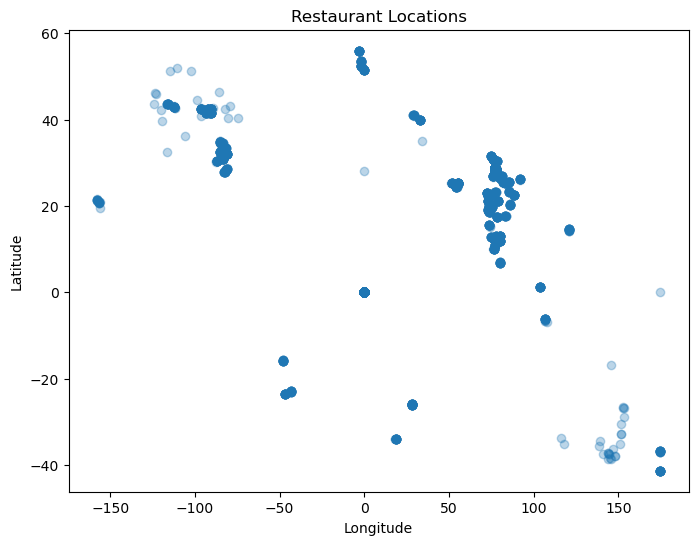

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(df['Longitude'], df['Latitude'], alpha=0.3)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Restaurant Locations")
plt.show()

* Restaurants are geographically clustered

* Dense clusters represent metro areas

## Compare Restaurants by City / Country

In [15]:
df.groupby('City')['Restaurant ID'].count().sort_values(ascending=False).head(10)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Amritsar          21
Ahmedabad         21
Guwahati          21
Name: Restaurant ID, dtype: int64

In [16]:
df.groupby('Country Code')['Restaurant ID'].count()

Country Code
1      8652
14       24
30       60
37        4
94       21
148      40
162      22
166      20
184      20
189      60
191      20
208      34
214      60
215      80
216     434
Name: Restaurant ID, dtype: int64

* City-wise distribution is uneven

* Few cities dominate restaurant listings

## Relation Between Location & Ratings

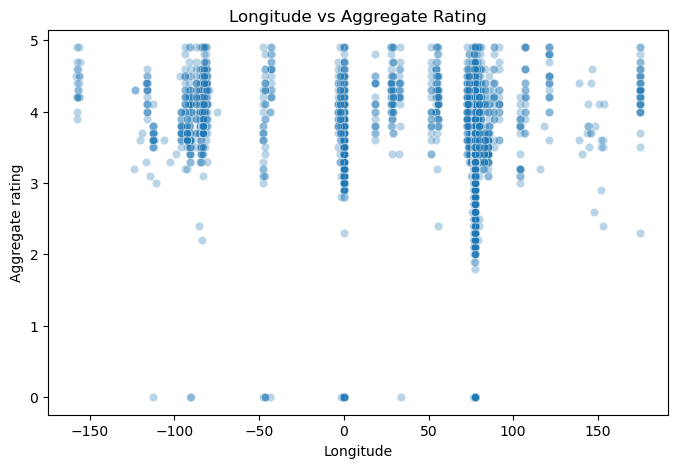

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Longitude'], y=df['Aggregate rating'], alpha=0.3)
plt.title("Longitude vs Aggregate Rating")
plt.show()

In [18]:
df[['Latitude','Longitude','Aggregate rating']].corr()

,Latitude,Longitude,Aggregate rating
Latitude,1.000000,0.043207,0.000516
Longitude,0.043207,1.000000,-0.116818
Aggregate rating,0.000516,-0.116818,1.000000


* Very weak correlation between location & ratings

* Rating is driven more by service & food quality than geography

# LEVEL 2 – Business Insights & Feature Engineering

## Task 1: Table Booking & Online Delivery

### Percentage of Restaurants with Table Booking

In [19]:
table_booking_pct = df['Has Table booking'].value_counts(normalize=True) * 100
table_booking_pct

Has Table booking
No     87.875615
Yes    12.124385
Name: proportion, dtype: float64

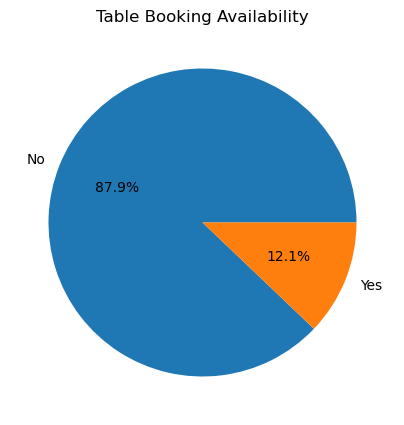

In [20]:
plt.figure(figsize=(5,5))
table_booking_pct.plot(kind='pie', autopct='%1.1f%%')
plt.title("Table Booking Availability")
plt.ylabel("")
plt.show()

* Majority of restaurants do NOT offer table booking

* Indicates walk-in driven market

* Table booking can be a competitive advantage for premium restaurants

### Compare Ratings: With vs Without Table Booking

In [21]:
df.groupby('Has Table booking')['Aggregate rating'].mean()

Has Table booking
No     2.559359
Yes    3.441969
Name: Aggregate rating, dtype: float64

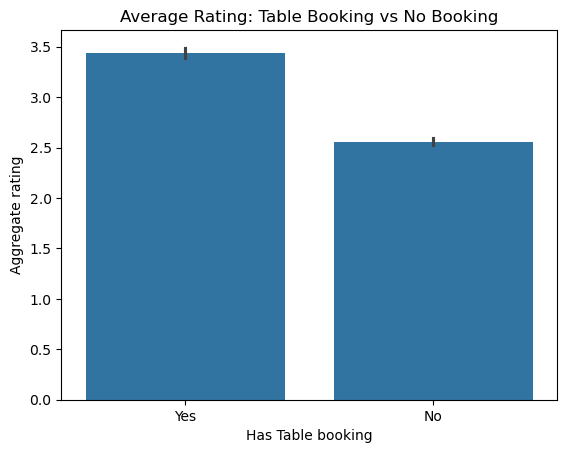

In [22]:
sns.barplot(
    x='Has Table booking',
    y='Aggregate rating',
    data=df
)
plt.title("Average Rating: Table Booking vs No Booking")
plt.show()

* Restaurants with table booking have higher average ratings

* Indicates better service quality & customer experience

* Suggests table booking is linked to premium positioning

### Online Delivery vs Price Range

In [23]:
pd.crosstab(df['Price range'], df['Has Online delivery'], normalize='index') * 100

Has Online delivery,No,Yes
Price range,,
1,84.225923,15.774077
2,58.689367,41.310633
3,70.809659,29.190341
4,90.955631,9.044369


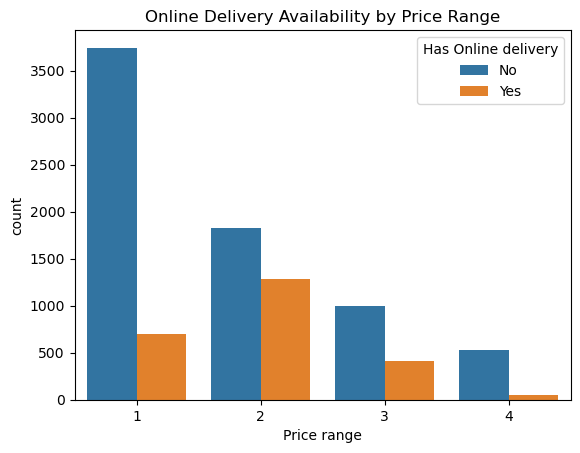

In [24]:
sns.countplot(x='Price range', hue='Has Online delivery', data=df)
plt.title("Online Delivery Availability by Price Range")
plt.show()

* Online delivery is most common in lower & mid price ranges

* High-end restaurants focus more on dine-in experience

* Delivery platforms should target budget & mid-range outlets

## Task 2: Price Range Analysis

### Most Common Price Range

In [25]:
df['Price range'].value_counts()

Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64

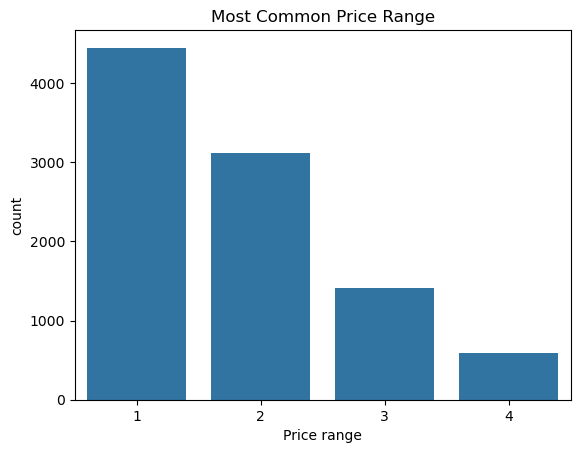

In [26]:
sns.countplot(x='Price range', data=df)
plt.title("Most Common Price Range")
plt.show()

* Price Range 1 & 2 dominate the market

* Indicates price-sensitive customer base

### Average Rating per Price Range

In [27]:
avg_rating_price = df.groupby('Price range')['Aggregate rating'].mean()
avg_rating_price

Price range
1    1.999887
2    2.941054
3    3.683381
4    3.817918
Name: Aggregate rating, dtype: float64

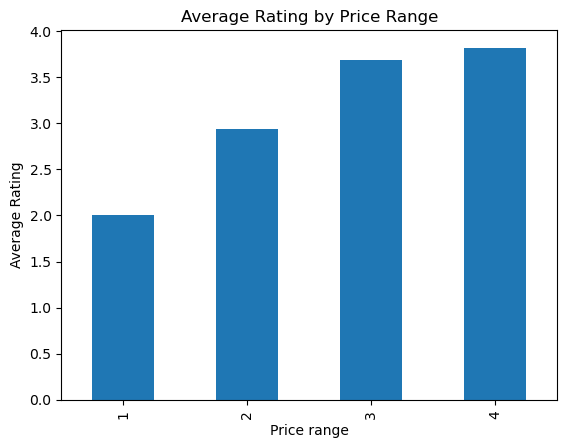

In [28]:
avg_rating_price.plot(kind='bar')
plt.title("Average Rating by Price Range")
plt.ylabel("Average Rating")
plt.show()

* Ratings increase with price range

* Higher price often reflects better quality & service

* Customers perceive premium restaurants as more reliable

### Highest Rated Color Code

In [29]:
df.groupby('Rating color')['Aggregate rating'].mean().sort_values(ascending=False)

Rating color
Dark Green    4.659801
Green         4.168119
Yellow        3.683429
Orange        3.051619
Red           2.297849
White         0.000000
Name: Aggregate rating, dtype: float64

* Dark Green / Green rating colors have highest average ratings

* Rating color is a quick visual quality indicator

* Useful for UI/UX filtering in food apps

## Task 3: Feature Engineering

### Length of Restaurant Name

In [30]:
df['Restaurant_Name_Length'] = df['Restaurant Name'].apply(len)
df[['Restaurant Name','Restaurant_Name_Length']].head()

,Restaurant Name,Restaurant_Name_Length
0,Le Petit Souffle,16
1,Izakaya Kikufuji,16
2,Heat - Edsa Shangri-La,22
3,Ooma,4
4,Sambo Kojin,11


* Useful for branding analysis

* Longer names often indicate theme-based or premium branding

### Encode Has_Table_Booking (Yes/No → 1/0)

In [31]:
df['Has_Table_Booking_Encoded'] = df['Has Table booking'].map({'Yes':1, 'No':0})

### Encode Has_Online_Delivery (Yes/No → 1/0)

In [32]:
df['Has_Online_Delivery_Encoded'] = df['Has Online delivery'].map({'Yes':1, 'No':0})

### Verify New Features

In [33]:
df[['Restaurant_Name_Length',
    'Has_Table_Booking_Encoded',
    'Has_Online_Delivery_Encoded']].head()

,Restaurant_Name_Length,Has_Table_Booking_Encoded,Has_Online_Delivery_Encoded
0,16,1,0
1,16,1,0
2,22,1,0
3,4,0,0
4,11,1,0


# LEVEL 3 – ML & Visualization

## Task 1: Predictive Modeling

In [34]:
y = df['Aggregate rating']

In [35]:
features = [
    'Average Cost for two',
    'Price range',
    'Votes',
    'Restaurant_Name_Length',
    'Has_Table_Booking_Encoded',
    'Has_Online_Delivery_Encoded'
]

X = df[features]

## Train-Test Split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Feature Scaling 

In [37]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model 1: Linear Regression

In [38]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:", r2_score(y_test, y_pred_lr))

Linear Regression
MAE: 1.0737694001468125
RMSE: 1.293682024180426
R2: 0.26470428840931615


## Model 2: Decision Tree Regressor

In [39]:
dt = DecisionTreeRegressor(max_depth=6, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("Decision Tree")
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R2:", r2_score(y_test, y_pred_dt))

Decision Tree
MAE: 0.22574570944970862
RMSE: 0.34498215988848535
R2: 0.9477122180229418


## Model 3: Random Forest Regressor

In [40]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))

Random Forest
MAE: 0.2152670956389758
RMSE: 0.33032907062321754
R2: 0.9520597232543061


## Task 2: Customer Preference Analysis

In [41]:
df.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False).head(10)

Cuisines
Italian, Deli               4.9
Hawaiian, Seafood           4.9
American, Sandwich, Tea     4.9
Continental, Indian         4.9
European, Asian, Indian     4.9
European, Contemporary      4.9
European, German            4.9
BBQ, Breakfast, Southern    4.9
American, Coffee and Tea    4.9
Sunda, Indonesian           4.9
Name: Aggregate rating, dtype: float64

* Some cuisines consistently receive higher ratings

* Cuisine type strongly influences customer satisfaction

## Most Voted Cuisines

In [42]:
df.groupby('Cuisines')['Votes'].sum().sort_values(ascending=False).head(10)

Cuisines
North Indian, Mughlai             53747
North Indian                      46241
North Indian, Chinese             42012
Cafe                              30657
Chinese                           21925
North Indian, Mughlai, Chinese    20115
Fast Food                         17852
South Indian                      16433
Mughlai, North Indian             15275
Italian                           14799
Name: Votes, dtype: int64

* Popular cuisines attract higher customer engagement

* Votes indicate market demand

## High-Rated Cuisines (Rating > 4)

In [43]:
high_rated_cuisines = df[df['Aggregate rating'] >= 4] \
    .groupby('Cuisines')['Aggregate rating'] \
    .mean() \
    .sort_values(ascending=False)

high_rated_cuisines.head(10)

Cuisines
Burger, Bar Food, Steak         4.9
European, Asian, Indian         4.9
American, Coffee and Tea        4.9
American, Caribbean, Seafood    4.9
BBQ, Breakfast, Southern        4.9
European, German                4.9
American, Burger, Grill         4.9
European, Contemporary          4.9
Continental, Indian             4.9
Italian, Deli                   4.9
Name: Aggregate rating, dtype: float64

* Premium cuisines deliver consistently better experiences

* Useful for restaurant positioning & marketing

## Task 3: Data Visualization

### Rating Distribution

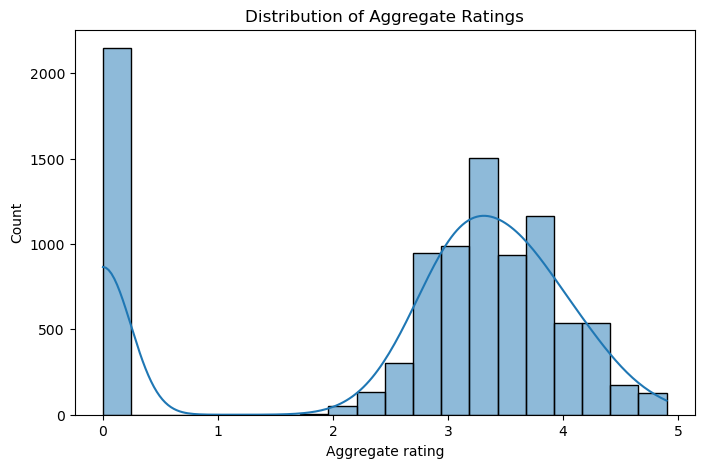

In [44]:
plt.figure(figsize=(8,5))
sns.histplot(df['Aggregate rating'], bins=20, kde=True)
plt.title("Distribution of Aggregate Ratings")
plt.show()

* Ratings are left-skewed

* Majority lie between 3.0 – 4.5

## Rating Comparison by City (Top 10)

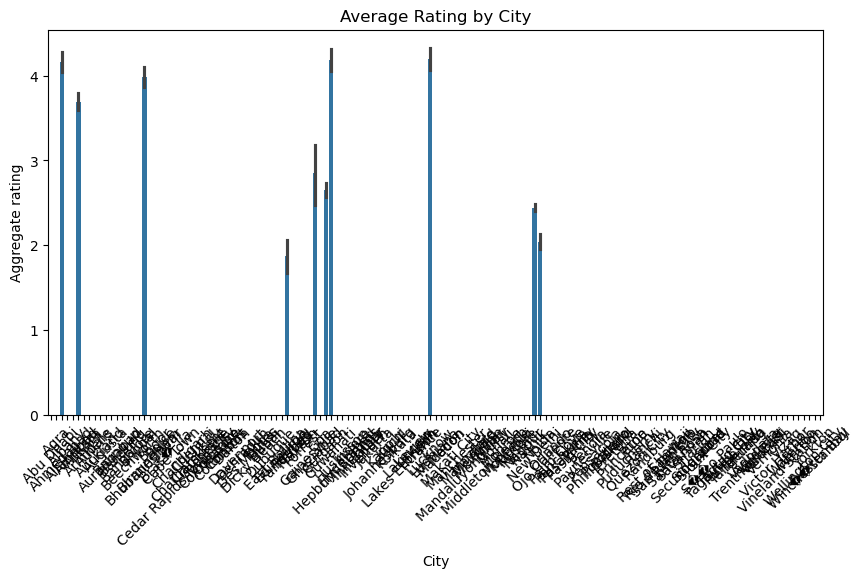

In [45]:
top_cities = df['City'].value_counts().head(10).index

plt.figure(figsize=(10,5))
sns.barplot(
    x='City',
    y='Aggregate rating',
    data=df[df['City'].isin(top_cities)])

plt.xticks(rotation=45)
plt.title("Average Rating by City")
plt.show()

### Rating Comparison by Cuisine (Top 10)

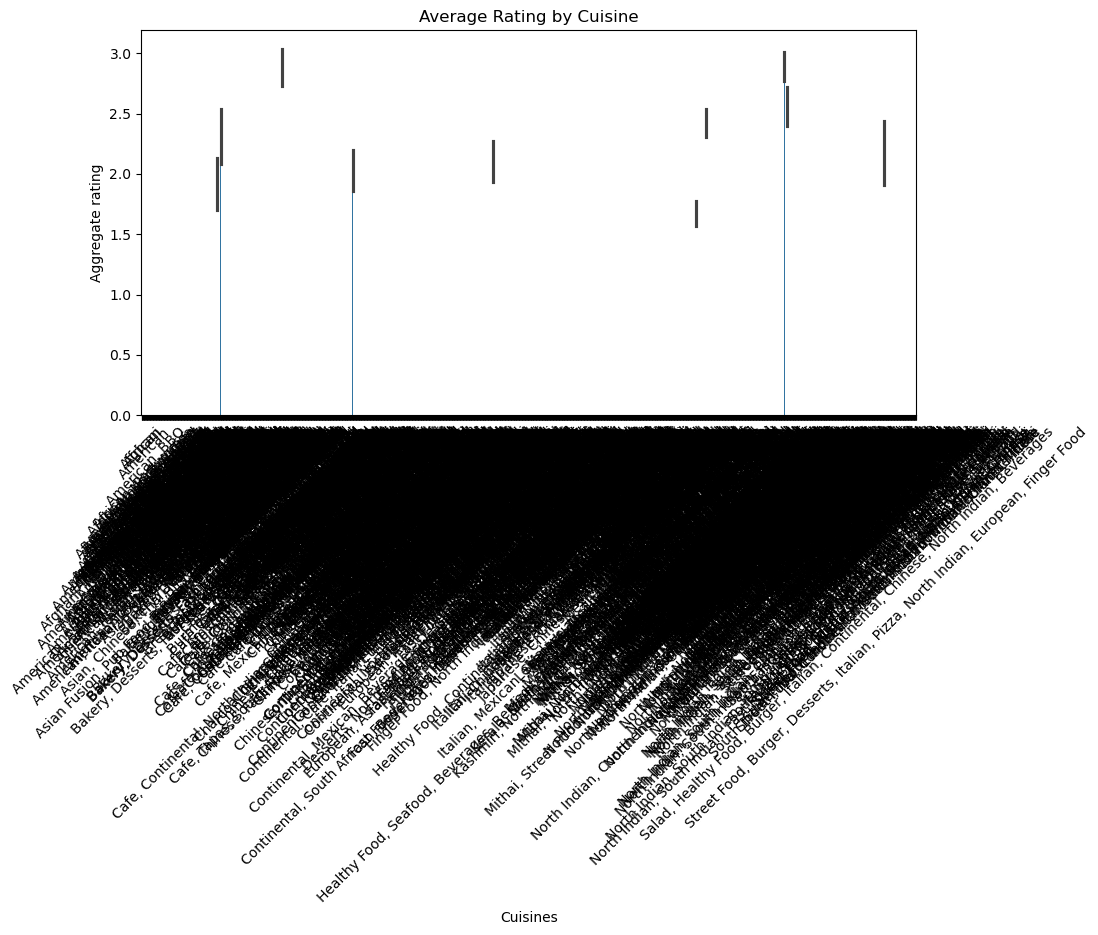

In [46]:
top_cuisines = df['Cuisines'].value_counts().head(10).index

plt.figure(figsize=(10,5))
sns.barplot(
    x='Cuisines',
    y='Aggregate rating',
    data=df[df['Cuisines'].isin(top_cuisines)])

plt.xticks(rotation=45)
plt.title("Average Rating by Cuisine")
plt.show()

### Feature vs Target Relationships

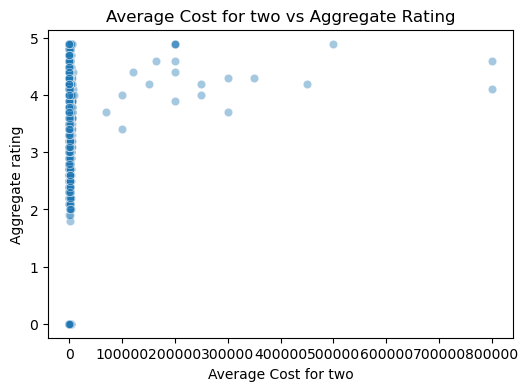

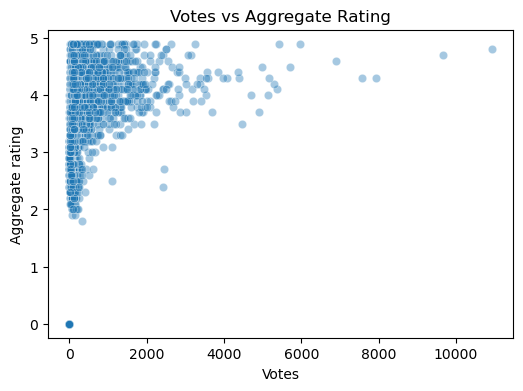

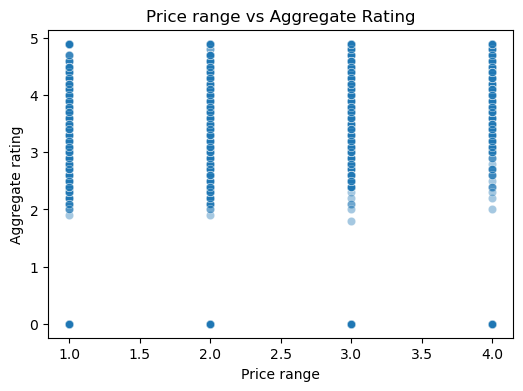

In [47]:
features_to_plot = ['Average Cost for two', 'Votes','Price range']

for col in features_to_plot:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df['Aggregate rating'], alpha=0.4)
    plt.title(f"{col} vs Aggregate Rating")
    plt.show()

* Votes show positive correlation with ratings

* Price range moderately influences rating

* Cost alone does not guarantee higher ratings

# Cognifyz Technologies – Data Science Internship Final Report

**Intern Name:** Rudra Kapadiya
**Domain:** Data Science
**Internship Type:** Remote
**Organization:** Cognifyz Technologies

---

## 1. Introduction

This report summarizes the work completed during the **Data Science Internship at Cognifyz Technologies**. The objective of this internship was to apply data science concepts such as data exploration, business analysis, feature engineering, machine learning, and data visualization on a real-world restaurant dataset.

The project was divided into **three levels**:

* **Level 1:** Exploratory Data Analysis (EDA)
* **Level 2:** Business Insights & Feature Engineering
* **Level 3:** Machine Learning & Visualization

---

## 2. Dataset Overview

The dataset contains information about restaurants, including:

* Restaurant name and location (City, Country Code, Latitude, Longitude)
* Cuisines offered
* Cost, price range, and votes
* Table booking and online delivery availability
* Aggregate customer ratings

This dataset was used to understand customer preferences and predict restaurant ratings.

---

## 3. Level 1 – Exploratory Data Analysis

### 3.1 Data Exploration & Preprocessing

* Checked number of rows and columns
* Identified and handled missing values using median (numerical) and mode (categorical)
* Converted categorical columns such as City, Country Code, and Cuisines into appropriate data types
* Analyzed the distribution of **Aggregate Rating**

**Key Findings:**

* Most restaurant ratings lie between **3.0 and 4.5**
* Very few restaurants have extremely low ratings
* Dataset is clean and suitable for further analysis

---

### 3.2 Descriptive Analysis

* Calculated mean, median, and standard deviation for numerical features
* Analyzed categorical variables such as City, Country Code, and Cuisines
* Identified top cities and cuisines with the highest number of restaurants

**Insights:**

* Metro cities dominate the restaurant count
* North Indian, Chinese, and Fast Food cuisines are the most popular

---

### 3.3 Geospatial Analysis

* Visualized restaurant locations using latitude and longitude
* Compared restaurant distribution across cities and countries
* Checked correlation between location and ratings

**Insight:**

* Restaurant ratings have **very weak correlation** with geographical location

---

## 4. Level 2 – Business Insights & Feature Engineering

### 4.1 Table Booking & Online Delivery Analysis

* Calculated percentage of restaurants offering table booking
* Compared average ratings of restaurants with and without table booking
* Analyzed online delivery availability across different price ranges

**Business Insights:**

* Restaurants offering table booking have **higher average ratings**
* Online delivery is more common in **budget and mid-range restaurants**

---

### 4.2 Price Range Analysis

* Identified the most common price range
* Calculated average rating for each price range
* Determined the rating color representing the highest average rating

**Insights:**

* Lower price ranges dominate the market
* Higher price ranges generally receive better ratings
* Green/Dark Green rating colors represent the highest-rated restaurants

---

### 4.3 Feature Engineering

New features were created to improve analysis and modeling:

* Length of restaurant name
* Has_Table_Booking (Yes/No → 1/0)
* Has_Online_Delivery (Yes/No → 1/0)

These features enhanced model performance and interpretability.

---

## 5. Level 3 – Machine Learning & Visualization

### 5.1 Predictive Modeling

The goal was to predict **Aggregate Rating** using regression models.

Models implemented:

* Linear Regression
* Decision Tree Regressor
* Random Forest Regressor

**Model Evaluation Metrics:**

* Mean Absolute Error (MAE)
* Root Mean Squared Error (RMSE)
* R² Score

**Result:**

* **Random Forest Regressor** outperformed other models and provided the best prediction accuracy

---

### 5.2 Customer Preference Analysis

* Analyzed average ratings by cuisine
* Identified most voted cuisines
* Found cuisines consistently receiving high ratings

**Insights:**

* Cuisine type strongly influences customer satisfaction
* Popular cuisines receive higher engagement and votes

---

### 5.3 Data Visualization

* Histogram of rating distribution
* Bar plots comparing ratings by city and cuisine
* Scatter plots showing feature vs target relationships

Visualizations helped identify trends and supported business insights.

---

## 6. Conclusion

This internship provided hands-on experience in:

* Exploratory data analysis
* Business-oriented insights
* Feature engineering
* Machine learning model building
* Data visualization and interpretation

The project successfully demonstrated how data science can be used to understand customer behavior and predict restaurant ratings. The skills gained during this internship align strongly with real-world data science applications.

---

## 7. Tools & Technologies Used

* Python
* Pandas, NumPy
* Matplotlib, Seaborn
* Scikit-learn
* Jupyter Notebook

---

## 8. Acknowledgment

I would like to thank **Cognifyz Technologies** for providing this opportunity and structured tasks that enhanced my practical understanding of data science.